In [1]:
# --- Importações Essenciais ---
import os
import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

# --- Importações do Scikit-learn ---
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from scipy import sparse
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    auc
)

# --- Configurações de Visualização ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [2]:
# Definir o caminho para os dados processados
processed_data_path = '../../data/processed/cidds_dataset'
train_proc_path = os.path.join(processed_data_path, 'train_processed.npz')
test_proc_path = os.path.join(processed_data_path, 'test_processed.npz')

# Carregar os arrays NumPy
train_data = np.load(train_proc_path, allow_pickle=True)
test_data = np.load(test_proc_path, allow_pickle=True)
X_test = test_data['X'].item()
y_test = test_data['y']
X_full = train_data['X'].item()
y_full = train_data['y']

# **Divisão Estratégica em Treino, Validação e Teste**
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=(1/7),
    random_state=42,
    stratify=y_full
)

# Verificar as dimensões finais
print("Divisão final dos dados:")
print(f"Treino (X, y):    \t{X_train.shape}, {y_train.shape}")
print(f"Validação (X, y): \t{X_val.shape}, {y_val.shape}")
print(f"Teste (X, y):     \t{X_test.shape}, {y_test.shape}")

# Manter nomenclatura, sem PCA por enquanto
X_train_pca = X_train
X_val_pca   = X_val
X_test_pca  = X_test

Divisão final dos dados:
Treino (X, y):    	(81453, 238), (81453,)
Validação (X, y): 	(13576, 238), (13576,)
Teste (X, y):     	(56303, 238), (56303,)


In [3]:
# Para a abordagem não supervisionada, o modelo deve aprender o que é "normal".
# Portanto, treinaremos o modelo APENAS com os dados da classe Normal (0).
print("--- Preparando dados para abordagem não supervisionada ---")

X_train_normal_only = X_train[y_train == 1] # TESTE INVERTENDO A LÓGICA COM ANOMALIA COMO CLASSE MAJORITARIA

print(f"Formato do conjunto de treino original: {X_train.shape}")
print(f"Formato do novo conjunto de treino (apenas normais): {X_train_normal_only.shape}")

# O parâmetro 'contamination' do Isolation Forest precisa de uma estimativa
# da proporção de anomalias no dataset. Usaremos a proporção do set de treino.
contamination_rate = np.mean(y_train == 0)
print(f"\nTaxa de contaminação (anomalias) estimada no treino: {contamination_rate:.4f}")

--- Preparando dados para abordagem não supervisionada ---
Formato do conjunto de treino original: (81453, 238)
Formato do novo conjunto de treino (apenas normais): (60218, 238)

Taxa de contaminação (anomalias) estimada no treino: 0.2607


In [4]:
# Grade de hiperparâmetros a ser explorada para o Isolation Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.5, 0.75, 1.0],
    'contamination': [contamination_rate] # Usaremos a taxa estimada como fixa no tuning
}
print(float(param_grid['contamination'][0]))

# Lista para armazenar os resultados
results_list = []

n_repeats = 5

print("Grade de parâmetros do Isolation Forest definida.")

0.2607024910070838
Grade de parâmetros do Isolation Forest definida.


In [5]:
total_runs = len(param_grid['n_estimators']) * len(param_grid['max_samples'] * n_repeats)
current_run = 0

print(f"Iniciando a busca em grade para o Isolation Forest... Total de {total_runs} execuções.")

for n_est in param_grid['n_estimators']:
    for m_samples in param_grid['max_samples']:
        for i in range(n_repeats):
            current_run += 1
            print(f"Execução {current_run}/{total_runs}: n_est={n_est}, max_samples={m_samples}")
            
            model = IsolationForest(
                n_estimators=n_est,
                max_samples=m_samples,
                contamination=float(contamination_rate),
                random_state=42,
                n_jobs=-1
            )
    
            start_time = time.time()
            # Treinamos apenas nos dados normais
            model.fit(X_train_normal_only)
            train_time = time.time() - start_time
    
            # Para avaliação, usei o conjunto de validação com ambas as classes
            # Mapear previsões: 1 (normal) -> 0, -1 (anomalia) -> 1
            y_pred_val = np.where(model.predict(X_val_pca) == 1, 0, 1)
            
            # Obter scores de anomalia
            anomaly_scores = model.decision_function(X_val_pca)
    
            results_list.append({
                'n_estimators': n_est, 'max_samples': m_samples,
                'train_time': train_time,
                'f1_score': f1_score(y_val, y_pred_val),
                'precision': precision_score(y_val, y_pred_val, zero_division=0),
                'recall': recall_score(y_val, y_pred_val, zero_division=0),
                # Para ROC AUC, scores maiores devem indicar a classe positiva (1).
                # Como scores MENORES indicam anomalia, usamos o negativo do score.
                'roc_auc': roc_auc_score(y_val, -anomaly_scores)
            })

print("\nBusca em grade concluída!")

Iniciando a busca em grade para o Isolation Forest... Total de 45 execuções.
Execução 1/45: n_est=50, max_samples=0.5
Execução 2/45: n_est=50, max_samples=0.5
Execução 3/45: n_est=50, max_samples=0.5
Execução 4/45: n_est=50, max_samples=0.5
Execução 5/45: n_est=50, max_samples=0.5
Execução 6/45: n_est=50, max_samples=0.75
Execução 7/45: n_est=50, max_samples=0.75
Execução 8/45: n_est=50, max_samples=0.75
Execução 9/45: n_est=50, max_samples=0.75
Execução 10/45: n_est=50, max_samples=0.75
Execução 11/45: n_est=50, max_samples=1.0
Execução 12/45: n_est=50, max_samples=1.0
Execução 13/45: n_est=50, max_samples=1.0
Execução 14/45: n_est=50, max_samples=1.0
Execução 15/45: n_est=50, max_samples=1.0
Execução 16/45: n_est=100, max_samples=0.5
Execução 17/45: n_est=100, max_samples=0.5
Execução 18/45: n_est=100, max_samples=0.5
Execução 19/45: n_est=100, max_samples=0.5
Execução 20/45: n_est=100, max_samples=0.5
Execução 21/45: n_est=100, max_samples=0.75
Execução 22/45: n_est=100, max_samples

In [6]:
results_df = pd.DataFrame(results_list)
results_df.to_csv('../../reports/cidds_reports/isoforest_tuning_detailed.csv', index=False)
agg_results_df = results_df.groupby(['n_estimators', 'max_samples']).mean().reset_index()
agg_results_df['composite_score'] = (agg_results_df['f1_score'] + agg_results_df['roc_auc']) / 2
best_params = agg_results_df.sort_values(by='composite_score', ascending=False).iloc[0]

print("--- Melhores Hiperparâmetros para o Isolation Forest Encontrados ---")
print(best_params)

agg_results_df.to_csv('../../reports/cidds_reports/isoforest_tuning_aggregated.csv', index=False)

--- Melhores Hiperparâmetros para o Isolation Forest Encontrados ---
n_estimators       200.000000
max_samples          0.750000
train_time           1.632799
f1_score             0.422363
precision            0.986467
recall               0.268706
roc_auc              0.810195
composite_score      0.616279
Name: 7, dtype: float64


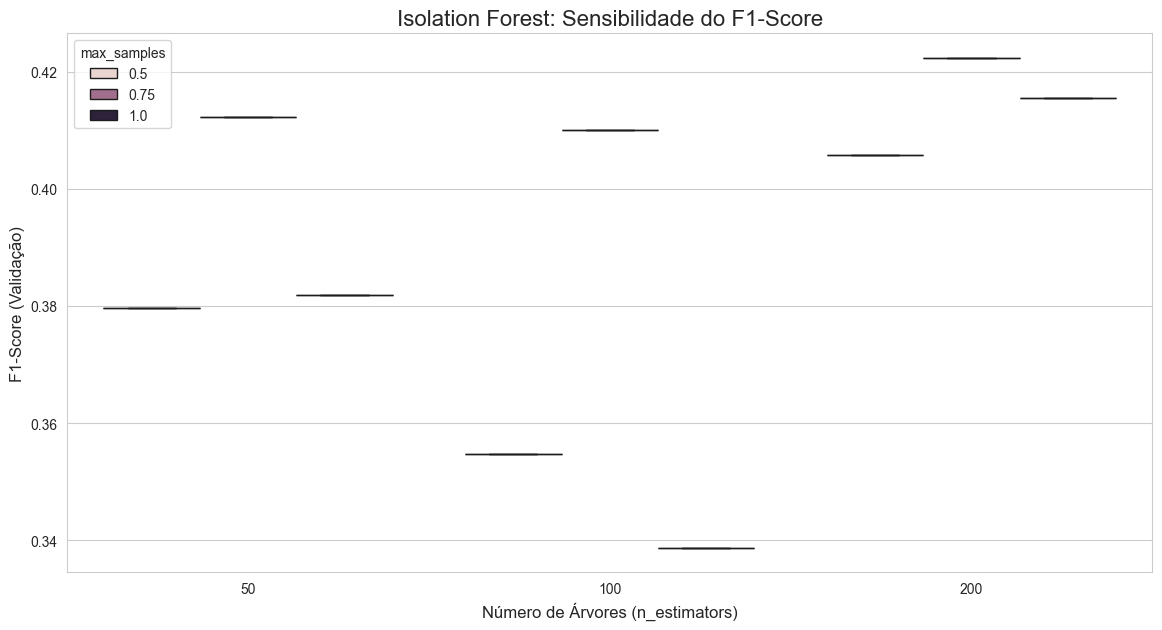

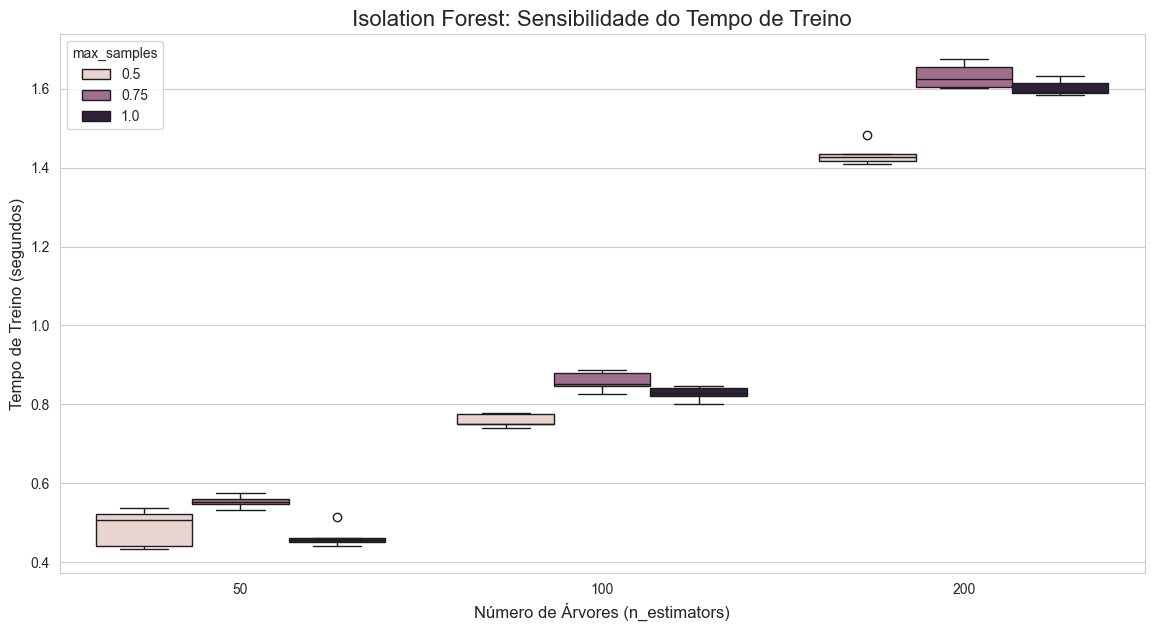

In [7]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='n_estimators', y='f1_score', hue='max_samples', data=results_df)
plt.title('Isolation Forest: Sensibilidade do F1-Score', fontsize=16)
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('F1-Score (Validação)', fontsize=12)
plt.show()

plt.figure(figsize=(14, 7))
sns.boxplot(x='n_estimators', y='train_time', hue='max_samples', data=results_df)
plt.title('Isolation Forest: Sensibilidade do Tempo de Treino', fontsize=16)
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('Tempo de Treino (segundos)', fontsize=12)
plt.show()

--- Otimização do Limiar de Decisão (Validation Set) ---

Melhor Limiar de Decisão encontrado (no score original): 0.0118


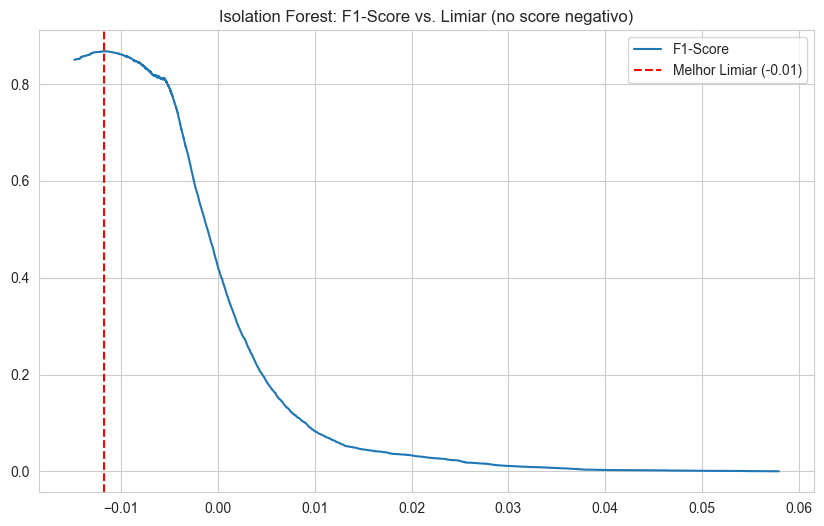

In [8]:
print("--- Otimização do Limiar de Decisão (Validation Set) ---")

# Instanciar o modelo com os melhores hiperparâmetros
model_for_tuning = IsolationForest(
    n_estimators=int(best_params['n_estimators']),
    max_samples=best_params['max_samples'],
    contamination=contamination_rate,
    random_state=42, n_jobs=-1
)
model_for_tuning.fit(X_train_normal_only)

# Obter os scores de anomalia. Scores mais baixos indicam maior anomalia.
anomaly_scores_val = model_for_tuning.decision_function(X_val_pca)

# Para a curva PR, precisamos que scores maiores indiquem a classe positiva (anomalia).
# Portanto, usamos o negativo dos scores.
precision, recall, thresholds = precision_recall_curve(y_val, -anomaly_scores_val)

# Os limiares retornados serão negativos. Calculamos o F1 e encontramos o melhor.
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold_idx = np.argmax(f1_scores)
best_threshold_on_negative_score = thresholds[best_threshold_idx]

# O limiar de decisão final será no score original.
best_threshold = -best_threshold_on_negative_score
print(f"\nMelhor Limiar de Decisão encontrado (no score original): {best_threshold:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.title("Isolation Forest: F1-Score vs. Limiar (no score negativo)")
plt.axvline(best_threshold_on_negative_score, color='r', linestyle='--', label=f'Melhor Limiar ({best_threshold_on_negative_score:.2f})')
plt.legend()
plt.show()

Formato do conjunto de treino final (apenas normais): (24774, 238)

Treinando o modelo final Isolation Forest...
Treino concluído.

--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00     24780
    Anomalia       0.56      1.00      0.72     31523

    accuracy                           0.56     56303
   macro avg       0.28      0.50      0.36     56303
weighted avg       0.31      0.56      0.40     56303


ROC AUC (Teste): 0.9912
--- Matriz de Confusão com Limiar Otimizado (Conjunto de Teste) ---


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

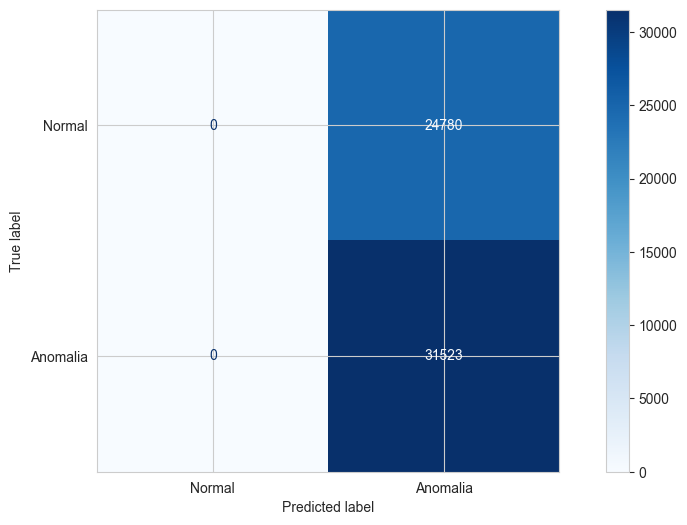

In [9]:
# Combinar dados de treino e validação
X_train_full = sparse.vstack((X_train, X_val))
y_train_full = np.concatenate((y_train, y_val))

# Criar o conjunto de treino final APENAS com dados normais
X_train_full_normal_only = X_train_full[y_train_full == 0]
print(f"Formato do conjunto de treino final (apenas normais): {X_train_full_normal_only.shape}")

# Instanciar o modelo final com os melhores hiperparâmetros
final_model = IsolationForest(
    n_estimators=int(best_params['n_estimators']),
    max_samples=best_params['max_samples'],
    contamination=contamination_rate,
    random_state=42, n_jobs=-1
)

print("\nTreinando o modelo final Isolation Forest...")
final_model.fit(X_train_full_normal_only)
print("Treino concluído.")

# Fazer previsões no conjunto de teste obtendo os scores
anomaly_scores_test = final_model.decision_function(X_test_pca)

# Aplicar o melhor limiar encontrado: uma amostra é anomalia (1) se seu score for MENOR que o limiar
y_pred_test_tuned = (anomaly_scores_test < best_threshold).astype(int)

# Avaliar o desempenho final
print("\n--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---")
print(classification_report(y_test, y_pred_test_tuned, target_names=['Normal', 'Anomalia']))

# Para o ROC AUC, lembre-se de usar o negativo dos scores
roc_auc_test = roc_auc_score(y_test, -anomaly_scores_test)
print(f"\nROC AUC (Teste): {roc_auc_test:.4f}")

# Visualizar a Matriz de Confusão
print("--- Matriz de Confusão com Limiar Otimizado (Conjunto de Teste) ---")
cm_tuned = confusion_matrix(y_test, y_pred_test_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Normal', 'Anomalia'])
disp_tuned.plot(cmap=plt.cm.Blues)
plt.show()